In [1]:
from pathlib import Path

print(Path.cwd())

/home/dyretna/Dokument/Code/Local/01_personal_projects/AI_fractals/notebooks


In [2]:
from dotenv import load_dotenv
import os

load_dotenv()

PROJECT_DIR = Path(os.getenv("PROJECT_DIR"))
PROJECT_DIR.exists()

True

# AI-Enhanced shoreline extraction

### Methodology for Generating Fractal Images
The first step in AI-enhanced fractal shoreline extraction involves generating
fractal images. This can be achieved using various mathematical methods, such as
iterated function systems (IFS), complex dynamics, or escape-time algorithms. For
illustration, we will focus on generating the Mandelbrot and Julia sets.

#### Generating the Mandelbrot Set: 
The Mandelbrot set is defined by iterating the
function zn+1=zn2+cz_{n+1} = z_n^2 + czn+1=zn2+c, where ccc is a complex
number and z0=0z_0 = 0z0=0. The set includes all points ccc for which the
sequence does not escape to infinity.

## mandelbrot set

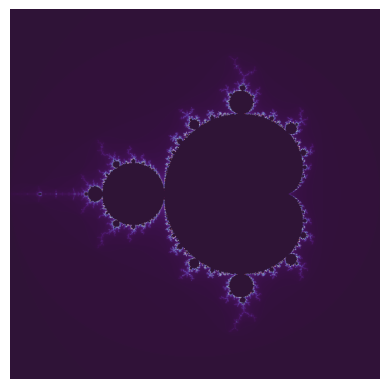

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def generate_mandelbrot(xmin, xmax, ymin, ymax, width, height, max_iter):
    x = np.linspace(xmin, xmax, width)
    y = np.linspace(ymin, ymax, height)
    X, Y = np.meshgrid(x, y)
    C = X + 1j * Y
    Z = np.zeros(C.shape, dtype=complex)

    img = np.zeros(C.shape, dtype=int)
    for i in range(max_iter):
        mask = np.abs(Z) < 2
        Z[mask] = Z[mask] * Z[mask] + C[mask]
        img += mask

    return img


# Generate and plot the mandelbrot set
mandelbrot_img = generate_mandelbrot(-2.0, 1.0, -1.5, 1.5, 800, 600, 256)
plt.imshow(mandelbrot_img, extent=[-2.0, 1.0, -1.5, 1.5], cmap='twilight_shifted')
plt.axis('off')
plt.savefig('mandelbrot.png', bbox_inches='tight', pad_inches=0)
plt.show()

## julia set

The Julia set is generated similarly but with a fixed
complex parameter ccc and varying initial values of zzz.

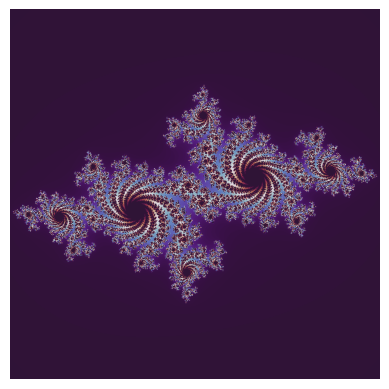

In [ ]:
def generate_julia(c, xmin, xmax, ymin, ymax, width, height, max_iter):
    x = np.linspace(xmin, xmax, width)
    y = np.linspace(ymin, ymax, height)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y

    img = np.zeros(Z.shape, dtype=int)
    for i in range(max_iter):
        mask = np.abs(Z) < 2
        Z[mask] = Z[mask] * Z[mask] + c
        img += mask

    return img

# Generate and plot the Julia set
julia_img = generate_julia(-0.7 + 0.27015j, -1.5, 1.5, -1.5, 1.5, 800, 600, 256)
plt.imshow(julia_img, extent=[-1.5, 1.5, -1.5, 1.5], cmap='twilight_shifted')
plt.axis('off')
plt.show()

# Techniques for Extracting Shorelines Using Image Processing

Once fractal images are generated, the next step is to extract their shorelines.
This involves identifying the boundaries or edges within the fractal image. Edge
detection algorithms are commonly used for this purpose.

### Using Canny Edge Detection: 
The Canny edge detection algorithm is effective for extracting edges from images. It involves several steps: noise reduction, gradient calculation, non-maximum suppression, and edge tracking by hysteresis.

In [ ]:
import cv2

def extract_shoreline(image):
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Apply Gaussian blur to reduce noise
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    # Use Canny edge detection to find edges
    edges = cv2.Canny(blurred, 50, 150)
    return edges


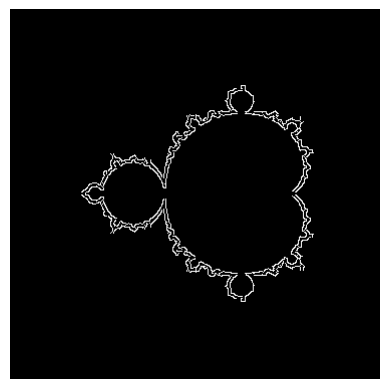

In [16]:
# Load the generated fractal image
fractal_img = cv2.imread('mandelbrot.png')
shoreline_img = extract_shoreline(fractal_img)

# Display the shoreline image
plt.imshow(shoreline_img, cmap='gray')
plt.axis('off')
plt.show()